# 02 Compute Metrics

Compute offline recommendation metrics and marketing-safe proxy KPIs for the DDM analytics layer.

This notebook does not train SR-GNN and does not create a new model split. It inherits the selected `v1_strict_filter` / `srgnn_fc` context from the backbone repo, including SR-GNN top-20 prediction rows exported from the already trained artifact.


In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs/project_config.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 160)

from ddm.io import load_config
from ddm.pipeline import inherit_recsys_context, compute_metrics_and_kpis


## Load Config

In [2]:
config = load_config(PROJECT_ROOT / "configs/project_config.yaml")
config["inheritance"]

{'data_version': 'v1_strict_filter',
 'model_profile': 'srgnn_fc',
 'top_k': 20,
 'inherited_root': 'data/inherited/recsys/v1_strict_filter_srgnn_fc_top20',
 'test_examples_path': 'data/inherited/recsys/v1_strict_filter_srgnn_fc_top20/test_examples.parquet',
 'predictions_path': 'data/inherited/recsys/v1_strict_filter_srgnn_fc_top20/predictions.parquet',
 'item_vocab_path': 'data/inherited/recsys/v1_strict_filter_srgnn_fc_top20/item_vocab.json',
 'metrics_path': 'data/inherited/recsys/v1_strict_filter_srgnn_fc_top20/metrics.json',
 'item_metadata_path': 'data/inherited/recsys/v1_strict_filter_srgnn_fc_top20/item_metadata.parquet'}

## Inherit SR-GNN Context

Required files are prepared under `data/inherited/recsys/v1_strict_filter_srgnn_fc_top20/`. `predictions.parquet` now contains SR-GNN top-20 rows exported from the already trained backbone artifact; no retraining or re-splitting is performed.


In [3]:
inheritance = inherit_recsys_context(PROJECT_ROOT)
inheritance

{'test_examples': WindowsPath('D:/NEU/MLOps/bigprj/ddm-diginetica-recommendation/data/inherited/recsys/v1_strict_filter_srgnn_fc_top20/test_examples.parquet'),
 'predictions': WindowsPath('D:/NEU/MLOps/bigprj/ddm-diginetica-recommendation/data/inherited/recsys/v1_strict_filter_srgnn_fc_top20/predictions.parquet'),
 'item_vocab': WindowsPath('D:/NEU/MLOps/bigprj/ddm-diginetica-recommendation/data/inherited/recsys/v1_strict_filter_srgnn_fc_top20/item_vocab.json'),
 'metrics': WindowsPath('D:/NEU/MLOps/bigprj/ddm-diginetica-recommendation/data/inherited/recsys/v1_strict_filter_srgnn_fc_top20/metrics.json'),
 'prediction_todo': None}

## Validate Inherited Schemas

In [4]:
inherited_root = PROJECT_ROOT / config["inheritance"]["inherited_root"]
test_examples = pd.read_parquet(inherited_root / "test_examples.parquet")
print(test_examples.shape)
test_examples.head()

(45910, 12)


,example_id,session_id,target_item_id_internal,target_item_id_raw,eventdate,item_seq_len,prefix_item_ids_internal,last_item_id_internal,last_item_id_raw,x,edge_index,alias_inputs
0,1,302,6635,36202,2016-05-26 00:00:00+00:00,2,"[6635, 1777]",1777,79520,"[6635, 1777]","[[0], [1]]","[0, 1]"
1,2,302,1777,79520,2016-05-26 00:00:00+00:00,1,[6635],6635,36202,[6635],"[[], []]",[0]
2,3,825,5626,19869,2016-06-01 00:00:00+00:00,5,"[5486, 2619, 2619, 10155, 2618]",2618,5723,"[5486, 2619, 10155, 2618]","[[0, 1, 1, 2], [1, 1, 2, 3]]","[0, 1, 1, 2, 3]"
3,4,825,2618,5723,2016-06-01 00:00:00+00:00,4,"[5486, 2619, 2619, 10155]",10155,25911,"[5486, 2619, 10155]","[[0, 1, 1], [1, 1, 2]]","[0, 1, 1, 2]"
4,5,825,10155,25911,2016-06-01 00:00:00+00:00,3,"[5486, 2619, 2619]",2619,5153,"[5486, 2619]","[[0, 1], [1, 1]]","[0, 1, 1]"


In [5]:
required_test_columns = {
    "example_id",
    "session_id",
    "target_item_id_internal",
    "target_item_id_raw",
    "eventdate",
}
missing = required_test_columns.difference(test_examples.columns)
assert not missing, f"Missing inherited test example columns: {sorted(missing)}"

predictions_path = inherited_root / "predictions.parquet"
if predictions_path.exists():
    predictions = pd.read_parquet(predictions_path)
    required_prediction_columns = {"example_id", "rank", "pred_item_id_internal", "pred_item_id_raw"}
    missing_predictions = required_prediction_columns.difference(predictions.columns)
    assert not missing_predictions, f"Missing prediction columns: {sorted(missing_predictions)}"
    print(predictions.shape)
    display(predictions.head())
else:
    todo_path = inherited_root / "PREDICTIONS_EXPORT_TODO.md"
    print("SR-GNN predictions.parquet is not available.")
    print(todo_path.read_text().splitlines()[0] if todo_path.exists() else "No TODO file found.")

(918200, 7)


,model_key,example_id,session_id,rank,pred_item_id_internal,pred_item_id_raw,score
0,srgnn_fc_v1_strict_filter_top20,1,302,1,6635,36202,None
1,srgnn_fc_v1_strict_filter_top20,1,302,2,1777,79520,None
2,srgnn_fc_v1_strict_filter_top20,1,302,3,6073,13806,None
3,srgnn_fc_v1_strict_filter_top20,1,302,4,2618,5723,None
4,srgnn_fc_v1_strict_filter_top20,1,302,5,5018,35141,None


## Compute Metrics and KPI Marts

The runner writes:

- `data/mart/fact_metrics.parquet`
- `data/mart/fact_marketing_kpis.parquet`
- `data/mart/fact_recommendations.parquet`
- `data/mart/fact_test_examples.parquet`
- `data/mart/fact_recommendation_eval.parquet`
- `data/mart/dim_model.parquet`

`fact_recommendations` contains long top-k rows for SR-GNN, popularity, and co-occurrence where available. `fact_recommendation_eval` is one row per model/example for session-level hit, rank, and value-proxy analysis.


In [ ]:
outputs = compute_metrics_and_kpis(PROJECT_ROOT)
outputs

d:\NEU\MLOps\bigprj\ddm-diginetica-recommendation\src\ddm\pipeline.py:412: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fact_recommendations = pd.concat(prediction_frames, ignore_index=True)
d:\NEU\MLOps\bigprj\ddm-diginetica-recommendation\src\ddm\kpis.py:157: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out["target_purchased_in_session"] = out["target_purchased_in_session"].fillna(False)
d:\NEU\MLOps\bigprj\ddm-diginetica-recommendation\src\ddm\kpis.py:157: FutureWarning: Downcasting object dtype arrays on .fillna, .ffil

{'fact_metrics': WindowsPath('D:/NEU/MLOps/bigprj/ddm-diginetica-recommendation/data/mart/fact_metrics.parquet'),
 'fact_marketing_kpis': WindowsPath('D:/NEU/MLOps/bigprj/ddm-diginetica-recommendation/data/mart/fact_marketing_kpis.parquet'),
 'fact_recommendations': WindowsPath('D:/NEU/MLOps/bigprj/ddm-diginetica-recommendation/data/mart/fact_recommendations.parquet'),
 'fact_test_examples': WindowsPath('D:/NEU/MLOps/bigprj/ddm-diginetica-recommendation/data/mart/fact_test_examples.parquet'),
 'fact_recommendation_eval': WindowsPath('D:/NEU/MLOps/bigprj/ddm-diginetica-recommendation/data/mart/fact_recommendation_eval.parquet'),
 'dim_model': WindowsPath('D:/NEU/MLOps/bigprj/ddm-diginetica-recommendation/data/mart/dim_model.parquet')}

## Offline Recommendation Metrics

In [ ]:
fact_metrics = pd.read_parquet(PROJECT_ROOT / "data/mart/fact_metrics.parquet")
fact_metrics.sort_values(["model_key", "metric_name"])

,model_key,metric_name,metric_value,k,metric_scope,source,warning_text
8,cooccurrence_top20,Catalog Coverage@20,0.966713,20,offline_test,computed_train_only_baseline,Offline next-click metric; not real CTR or causal business impact.
6,cooccurrence_top20,HR@20,0.300849,20,offline_test,computed_train_only_baseline,Offline next-click metric; not real CTR or causal business impact.
7,cooccurrence_top20,MRR@20,0.108070,20,offline_test,computed_train_only_baseline,Offline next-click metric; not real CTR or causal business impact.
5,popularity_top20,Catalog Coverage@20,0.000867,20,offline_test,computed_train_only_baseline,Offline next-click metric; not real CTR or causal business impact.
3,popularity_top20,HR@20,0.010129,20,offline_test,computed_train_only_baseline,Offline next-click metric; not real CTR or causal business impact.
4,popularity_top20,MRR@20,0.002292,20,offline_test,computed_train_only_baseline,Offline next-click metric; not real CTR or causal business impact.
2,srgnn_fc_v1_strict_filter_top20,Catalog Coverage@20,0.935506,20,offline_test,inherited_prediction_rows,Offline next-click metric; not real CTR or causal business impact.
0,srgnn_fc_v1_strict_filter_top20,HR@20,0.541625,20,offline_test,inherited_prediction_rows,Offline next-click metric; not real CTR or causal business impact.
1,srgnn_fc_v1_strict_filter_top20,MRR@20,0.183158,20,offline_test,inherited_prediction_rows,Offline next-click metric; not real CTR or causal business impact.


## Session-Centered Marketing Proxy KPIs

Safe wording:

- Recommendation Success Rate@20 is HR@20.
- CTR Proxy@20 is HR@20 in business language, not real CTR.
- GMV and purchase value fields are price-proxy based and offline only.
- Relative-delta rows are benchmark deltas, not causal revenue or conversion lift.

In [ ]:
fact_marketing_kpis = pd.read_parquet(PROJECT_ROOT / "data/mart/fact_marketing_kpis.parquet")
fact_marketing_kpis.sort_values(["model_key", "kpi_name"])

,model_key,k,kpi_name,kpi_value,kpi_scope,warning_text
17,cooccurrence_top20,20.0,CTR Proxy@20,3.008495e-01,offline_test_examples,CTR Proxy@K equals offline Hit Rate@K; it is not real CTR.
20,cooccurrence_top20,20.0,Captured GMV Proxy@20,4.847235e+06,offline_test_examples,"Offline proxy only: not real CTR, not causal conversion, and not audited revenue."
22,cooccurrence_top20,20.0,Captured Purchase Value Proxy@20,5.403400e+04,offline_test_examples,Only counts target items also purchased in the same session; not causal conversion.
19,cooccurrence_top20,20.0,Hit Rate@20 among purchase sessions,2.864245e-01,offline_test_examples,"Offline proxy only: not real CTR, not causal conversion, and not audited revenue."
18,cooccurrence_top20,NaN,Purchase Session Rate,4.067816e-02,all_sessions,Offline purchase/session proxy; not causal conversion after recommendation.
16,cooccurrence_top20,20.0,Recommendation Success Rate@20,3.008495e-01,offline_test_examples,"Offline proxy only: not real CTR, not causal conversion, and not audited revenue."
23,cooccurrence_top20,20.0,Relative delta vs popularity baseline HR@20,2.870323e+01,offline_test_examples,"Offline proxy only: not real CTR, not causal conversion, and not audited revenue."
24,cooccurrence_top20,20.0,Relative delta vs popularity baseline Revenue-weighted HR@20,2.249639e+01,offline_test_examples,"Offline proxy only: not real CTR, not causal conversion, and not audited revenue."
21,cooccurrence_top20,20.0,Revenue-weighted HR@20,3.027443e-01,offline_test_examples,"Offline proxy only: not real CTR, not causal conversion, and not audited revenue."
10,popularity_top20,20.0,CTR Proxy@20,1.012851e-02,offline_test_examples,CTR Proxy@K equals offline Hit Rate@K; it is not real CTR.


## Recommendation Rows

In [ ]:
fact_recommendations = pd.read_parquet(PROJECT_ROOT / "data/mart/fact_recommendations.parquet")
print(fact_recommendations.shape)
fact_recommendations.groupby("model_key").agg(
    rows=("example_id", "size"),
    examples=("example_id", "nunique"),
    unique_items=("pred_item_id_raw", "nunique"),
    min_rank=("rank", "min"),
    max_rank=("rank", "max"),
).reset_index()


(2754600, 7)


,model_key,rows,examples,unique_items,min_rank,max_rank
0,cooccurrence_top20,918200,45910,22304,1,20
1,popularity_top20,918200,45910,20,1,20
2,srgnn_fc_v1_strict_filter_top20,918200,45910,21584,1,20


## Per-Example Recommendation Evaluation


In [ ]:
fact_recommendation_eval = pd.read_parquet(PROJECT_ROOT / "data/mart/fact_recommendation_eval.parquet")
print(fact_recommendation_eval.shape)
fact_recommendation_eval.groupby("model_key").agg(
    rows=("example_id", "size"),
    examples=("example_id", "nunique"),
    hit_rate=("hit_at_k", "mean"),
    mean_reciprocal_rank=("reciprocal_rank", "mean"),
    captured_value_proxy=("captured_value_proxy", "sum"),
).reset_index()


(137730, 14)


,model_key,rows,examples,hit_rate,mean_reciprocal_rank,captured_value_proxy
0,cooccurrence_top20,45910,45910,0.300849,0.108070,4847235.0
1,popularity_top20,45910,45910,0.010129,0.002292,206297.0
2,srgnn_fc_v1_strict_filter_top20,45910,45910,0.541625,0.183158,8474426.0


In [19]:
import pandas as pd
import json, yaml

# config
with open(PROJECT_ROOT / "configs/project_config.yaml") as f:
    cfg = yaml.safe_load(f)

data_version   = cfg["inheritance"]["data_version"]
backbone       = (PROJECT_ROOT / cfg["paths"]["backbone_repo_path"]).resolve()
mart_root      = PROJECT_ROOT / cfg["outputs"]["mart_root"]
inherited_root = PROJECT_ROOT / cfg["inheritance"]["inherited_root"]
top_k          = int(cfg["inheritance"]["top_k"])
fact_kpis = pd.read_parquet(mart_root / "fact_marketing_kpis.parquet")

(
    fact_kpis
    .pivot(index="kpi_name", columns="model_key", values="kpi_value")
    .reset_index()
    .rename(columns={"kpi_name": "KPI"})
    .style
    .set_caption(f"KPI Comparison — all models @ K={top_k}")
    .format({c: "{:.4f}" for c in fact_kpis["model_key"].unique()}, na_rep="—")
    .hide(axis="index")
)

KPI,cooccurrence_top20,popularity_top20,srgnn_fc_v1_strict_filter_top20
CTR Proxy@20,0.3008,0.0101,0.5416
Captured GMV Proxy@20,4847235.0000,206297.0000,8474426.0000
Captured Purchase Value Proxy@20,54034.0000,6134.0000,173208.0000
Hit Rate@20 among purchase sessions,0.2864,0.0084,0.6379
Purchase Session Rate,0.0407,0.0407,0.0407
Recommendation Success Rate@20,0.3008,0.0101,0.5416
Relative delta vs popularity baseline HR@20,28.7032,—,52.4753
Relative delta vs popularity baseline Revenue-weighted HR@20,22.4964,—,40.0788
Revenue-weighted HR@20,0.3027,0.0129,0.5293


# Snapshot Data & KPI

In [ ]:
"""
DDM Dashboard — full per-model KPIs, zero hardcode.
Dán toàn bộ cell này vào notebook 02_compute_metrics.ipynb
Yêu cầu: PROJECT_ROOT đã được định nghĩa ở cell 1
"""

from IPython.display import display, HTML
import pandas as pd
import json, yaml

# ── 2. Dataset snapshot ────────────────────────────────────────────────────────
stats  = json.loads((backbone / "data/versions" / data_version / "processed/data_stats.json").read_text())
ingest = json.loads((backbone / "metrics/ingest_report.json").read_text())

n_train_sessions = stats["train"]["interactions"]["n_sessions"]
n_test_examples  = stats["test"]["examples"]
n_unique_items   = ingest["n_items"]
n_vocab_items    = stats["vocab_size"]

raw_views = pd.read_csv(PROJECT_ROOT / cfg["paths"]["raw_interactions_path"], sep=";", usecols=["userId"])
missing_user_pct = raw_views["userId"].isna().mean()

# ── 3. Mart data ───────────────────────────────────────────────────────────────
fact_metrics = pd.read_parquet(mart_root / "fact_metrics.parquet")
fact_kpis    = pd.read_parquet(mart_root / "fact_marketing_kpis.parquet")

# Exact KPI/metric name strings — từ kpis.py và metrics.py
MET_HR   = f"HR@{top_k}"
MET_MRR  = f"MRR@{top_k}"
MET_COV  = f"Catalog Coverage@{top_k}"

KPI_CTR        = f"CTR Proxy@{top_k}"
KPI_PURCH_RATE = "Purchase Session Rate"
KPI_HR_PURCH   = f"Hit Rate@{top_k} among purchase sessions"
KPI_GMV        = f"Captured GMV Proxy@{top_k}"
KPI_RW_HR      = f"Revenue-weighted HR@{top_k}"
KPI_PV         = f"Captured Purchase Value Proxy@{top_k}"
KPI_DELTA_HR   = f"Relative delta vs popularity baseline HR@{top_k}"
KPI_DELTA_RWHR = f"Relative delta vs popularity baseline Revenue-weighted HR@{top_k}"

def get_metric(model, name):
    if model is None: return None
    row = fact_metrics[(fact_metrics["model_key"] == model) & (fact_metrics["metric_name"] == name)]
    return float(row["metric_value"].iloc[0]) if len(row) else None

def get_kpi(model, name):
    if model is None: return None
    row = fact_kpis[(fact_kpis["model_key"] == model) & (fact_kpis["kpi_name"] == name)]
    return float(row["kpi_value"].iloc[0]) if len(row) else None

# ── 4. Model keys ──────────────────────────────────────────────────────────────
model_keys = fact_metrics["model_key"].unique().tolist()
pop_key   = next((k for k in model_keys if "pop"   in k.lower()), None)
coo_key   = next((k for k in model_keys if "coo"   in k.lower()), None)
srgnn_key = next((k for k in model_keys if "srgnn" in k.lower()), None)

# ── 5. SR-GNN metrics: mart → fallback inherited metrics.json ─────────────────
srgnn_hr  = get_metric(srgnn_key, MET_HR)
srgnn_mrr = get_metric(srgnn_key, MET_MRR)
srgnn_cov = get_metric(srgnn_key, MET_COV)

if srgnn_hr is None:
    srgnn_path = inherited_root / "metrics.json"
    if srgnn_path.exists():
        sm = json.loads(srgnn_path.read_text())
        srgnn_hr  = sm.get(MET_HR)  or sm.get("hr_at_20")  or sm.get(f"hr_at_{top_k}")
        srgnn_mrr = sm.get(MET_MRR) or sm.get("mrr_at_20") or sm.get(f"mrr_at_{top_k}")
        srgnn_cov = sm.get(MET_COV) or sm.get("coverage_at_20") or sm.get(f"coverage_at_{top_k}")

# ── 6. KPI values — đầy đủ cho tất cả model ───────────────────────────────────
# Purchase Session Rate: KPI cấp dataset, không phụ thuộc model → lấy từ pop
purch_rate = get_kpi(pop_key, KPI_PURCH_RATE)

# Per-model KPIs
pop_ctr        = get_kpi(pop_key,   KPI_CTR)
coo_ctr        = get_kpi(coo_key,   KPI_CTR)
srgnn_ctr      = get_kpi(srgnn_key, KPI_CTR)

pop_hr_purch   = get_kpi(pop_key,   KPI_HR_PURCH)
coo_hr_purch   = get_kpi(coo_key,   KPI_HR_PURCH)
srgnn_hr_purch = get_kpi(srgnn_key, KPI_HR_PURCH)

pop_gmv        = get_kpi(pop_key,   KPI_GMV)
coo_gmv        = get_kpi(coo_key,   KPI_GMV)
srgnn_gmv      = get_kpi(srgnn_key, KPI_GMV)

pop_rw_hr      = get_kpi(pop_key,   KPI_RW_HR)
coo_rw_hr      = get_kpi(coo_key,   KPI_RW_HR)
srgnn_rw_hr    = get_kpi(srgnn_key, KPI_RW_HR)

pop_pv         = get_kpi(pop_key,   KPI_PV)
coo_pv         = get_kpi(coo_key,   KPI_PV)
srgnn_pv       = get_kpi(srgnn_key, KPI_PV)

coo_delta_hr   = get_kpi(coo_key,   KPI_DELTA_HR)
srgnn_delta_hr = get_kpi(srgnn_key, KPI_DELTA_HR)

# SR-GNN GMV linear estimate nếu chưa có trong mart
srgnn_gmv_is_estimate = False
coo_hr_val = get_metric(coo_key, MET_HR)
if srgnn_gmv is None and coo_gmv and coo_hr_val and srgnn_hr:
    srgnn_gmv = coo_gmv / coo_hr_val * srgnn_hr
    srgnn_gmv_is_estimate = True

# ── 7. HTML helpers ────────────────────────────────────────────────────────────
def fmt(v, style="num4"):
    if v is None: return "—"
    if style == "num4": return f"{v:.4f}"
    if style == "pct1": return f"{v:.1%}"
    if style == "pct2": return f"{v:.2%}"
    if style == "gmv":  return f"{v:,.0f}"
    if style == "delta": return f"{v:+.0%}"
    return str(v)

def hr_bar(hr, all_hr_vals):
    if hr is None: return ""
    valid = [v for v in all_hr_vals if v is not None]
    if not valid: return ""
    max_hr = max(valid)
    pct    = hr / max_hr * 100
    color  = "#1D9E75" if hr == max_hr else "#3B8BD4" if hr > max_hr * 0.15 else "#777"
    return (f'<div style="background:#2a2a2a;border-radius:3px;height:6px;width:110px">'
            f'<div style="width:{pct:.1f}%;height:6px;border-radius:3px;background:{color}"></div></div>')

def model_label(key):
    if key is None: return "—"
    k = key.lower()
    if "pop"   in k: return "Popularity"
    if "coo"   in k: return "Co-occurrence"
    if "srgnn" in k: return f"SR-GNN ({cfg['inheritance']['model_profile']})"
    return key

BADGE_BG = {
    pop_key:   ("#3a3a3a", "#bbb"),
    coo_key:   ("#1a4a7a", "#7ab8f5"),
    srgnn_key: ("#145233", "#4ade80"),
}

def badge(key):
    bg, fg = BADGE_BG.get(key, ("#333", "#fff"))
    return (f'<span style="background:{bg};color:{fg};padding:3px 10px;'
            f'border-radius:4px;font-size:11px;font-weight:500">{model_label(key)}</span>')

def card(label, val_str, sub="", accent=None):
    color = f"color:{accent}" if accent else ""
    return (f'<div style="background:#1e1e1e;border-radius:8px;padding:12px 14px;flex:1;min-width:150px">'
            f'<div style="font-size:10px;color:#666;margin-bottom:5px">{label}</div>'
            f'<div style="font-size:18px;font-weight:600;{color}">{val_str}</div>'
            f'<div style="font-size:10px;color:#555;margin-top:2px">{sub}</div></div>')

def best(vals):
    """Trả về giá trị max trong list, dùng để highlight."""
    valid = [v for v in vals if v is not None]
    return max(valid) if valid else None

def val_cell(v, all_vals, style="num4"):
    """Highlight đậm nếu là giá trị tốt nhất."""
    s = fmt(v, style)
    if v is not None and v == best(all_vals):
        return f"<b style='color:#4ade80'>{s}</b>"
    return s

# ── 8. Accuracy table ──────────────────────────────────────────────────────────
rows_data = [
    (pop_key,   get_metric(pop_key,   MET_HR), get_metric(pop_key,   MET_MRR), get_metric(pop_key,   MET_COV)),
    (coo_key,   get_metric(coo_key,   MET_HR), get_metric(coo_key,   MET_MRR), get_metric(coo_key,   MET_COV)),
    (srgnn_key, srgnn_hr,                      srgnn_mrr,                      srgnn_cov),
]
all_hr  = [r[1] for r in rows_data if r[1] is not None]
all_mrr = [r[2] for r in rows_data if r[2] is not None]
all_cov = [r[3] for r in rows_data if r[3] is not None]

accuracy_rows = ""
for key, hr, mrr, cov in rows_data:
    if key is None: continue
    cov_color = "#4ade80" if cov and cov > 0.1 else "#f87171"
    inherited_note = (
        '<span style="font-size:10px;color:#555"> (metrics.json)</span>'
        if key == srgnn_key and get_metric(srgnn_key, MET_HR) is None else ""
    )
    accuracy_rows += f"""
    <tr>
      <td>{badge(key)}</td>
      <td>{val_cell(hr,  all_hr,  'num4')}{inherited_note}</td>
      <td>{val_cell(mrr, all_mrr, 'num4')}</td>
      <td><span style="color:{cov_color}">{fmt(cov,'pct1')}</span></td>
      <td>{hr_bar(hr, all_hr)}</td>
    </tr>"""

# ── 9. KPI table — full per-model ─────────────────────────────────────────────
def kpi_row(kpi_label, pop_v, coo_v, srgnn_v, style="num4", higher_is_better=True):
    vals = [pop_v, coo_v, srgnn_v]
    ref  = best(vals) if higher_is_better else (min([v for v in vals if v is not None]) if any(v is not None for v in vals) else None)
    def cell(v):
        s = fmt(v, style)
        return f"<b style='color:#4ade80'>{s}</b>" if (v is not None and v == ref) else s
    return f"""
    <tr>
      <td style="color:#aaa;font-size:12px">{kpi_label}</td>
      <td>{cell(pop_v)}</td>
      <td>{cell(coo_v)}</td>
      <td>{cell(srgnn_v)}</td>
    </tr>"""

srgnn_delta_sub = " (est.)" if srgnn_gmv_is_estimate else ""

kpi_table_rows = "".join([
    kpi_row(f"CTR Proxy@{top_k}",                   pop_ctr,        coo_ctr,        srgnn_ctr,        "pct2"),
    kpi_row(f"HR@{top_k} in purchase sessions",      pop_hr_purch,   coo_hr_purch,   srgnn_hr_purch,   "pct2"),
    kpi_row(f"Revenue-weighted HR@{top_k}",          pop_rw_hr,      coo_rw_hr,      srgnn_rw_hr,      "num4"),
    kpi_row(f"Captured GMV Proxy@{top_k}",           pop_gmv,        coo_gmv,        srgnn_gmv,        "gmv"),
    kpi_row(f"Captured Purchase Value Proxy@{top_k}",pop_pv,         coo_pv,         srgnn_pv,         "gmv"),
    kpi_row(f"Δ HR vs popularity baseline",          None,           coo_delta_hr,   srgnn_delta_hr,   "delta"),
])

# ── 10. Uplift summary cards ───────────────────────────────────────────────────
uplift_coo_gmv   = f"+{(coo_gmv - pop_gmv) / pop_gmv:.0%} vs pop"     if pop_gmv and coo_gmv   else ""
uplift_srgnn_gmv = f"+{(srgnn_gmv - coo_gmv) / coo_gmv:.0%} vs co-occ{srgnn_delta_sub}" if srgnn_gmv and coo_gmv else ""
uplift_coo_hr    = f"+{(get_metric(coo_key, MET_HR) - get_metric(pop_key, MET_HR)) / get_metric(pop_key, MET_HR):.0%} vs pop" \
                   if get_metric(coo_key, MET_HR) and get_metric(pop_key, MET_HR) else ""
uplift_srgnn_hr  = f"+{(srgnn_hr - get_metric(coo_key, MET_HR)) / get_metric(coo_key, MET_HR):.0%} vs co-occ" \
                   if srgnn_hr and get_metric(coo_key, MET_HR) else ""

summary_cards = "".join([
    card("Purchase Session Rate",                    fmt(purch_rate, "pct2"), "dataset-level, model-independent"),
    card(f"GMV Proxy — {model_label(pop_key)}",      fmt(pop_gmv,    "gmv"),  "baseline"),
    card(f"GMV Proxy — {model_label(coo_key)}",      fmt(coo_gmv,    "gmv"),  uplift_coo_gmv,   "#4ade80"),
    card(f"GMV Proxy — {model_label(srgnn_key)}",    fmt(srgnn_gmv,  "gmv"),  uplift_srgnn_gmv, "#4ade80"),
])

# ── 11. Render ─────────────────────────────────────────────────────────────────
html = f"""
<style>
.ddmdb{{font-family:'Segoe UI',system-ui,sans-serif;background:#141414;color:#e0e0e0;
        padding:24px;border-radius:12px;max-width:960px;line-height:1.4}}
.ddmdb .sec{{font-size:10px;font-weight:600;letter-spacing:.12em;text-transform:uppercase;
             color:#555;margin:22px 0 10px}}
.ddmdb .snap{{display:grid;grid-template-columns:repeat(4,1fr);gap:10px}}
.ddmdb .scard{{background:#1e1e1e;border-radius:8px;padding:14px 16px}}
.ddmdb .scard .lbl{{font-size:11px;color:#666;margin-bottom:4px}}
.ddmdb .scard .val{{font-size:22px;font-weight:600}}
.ddmdb .scard .sub{{font-size:11px;color:#555;margin-top:2px}}
.ddmdb table{{width:100%;border-collapse:collapse;font-size:13px}}
.ddmdb th{{text-align:left;font-size:10px;font-weight:600;color:#555;padding:6px 10px;
           border-bottom:1px solid #2a2a2a;letter-spacing:.06em;text-transform:uppercase}}
.ddmdb td{{padding:7px 10px;border-bottom:1px solid #1e1e1e;text-align:center}}
.ddmdb td:first-child{{text-align:left}}
.ddmdb th:first-child{{text-align:left}}
.ddmdb .cards{{display:flex;gap:10px;flex-wrap:wrap}}
.ddmdb .warn{{font-size:11px;color:#555;border-left:2px solid #2a2a2a;
              padding-left:10px;margin-top:16px;line-height:1.7}}
</style>
<div class="ddmdb">

  <div style="font-size:10px;font-weight:600;letter-spacing:.12em;text-transform:uppercase;color:#444;margin-bottom:14px">
    DATASET SNAPSHOT — DIGINETICA · <span style="color:#555">{data_version}</span>
  </div>
  <div class="snap">
    <div class="scard"><div class="lbl">Sessions (train)</div><div class="val">{n_train_sessions:,}</div></div>
    <div class="scard"><div class="lbl">Test examples</div><div class="val">{n_test_examples:,}</div></div>
    <div class="scard"><div class="lbl">Unique items (raw)</div><div class="val">{n_unique_items:,}</div><div class="sub">vocab sau filter: {n_vocab_items:,}</div></div>
    <div class="scard"><div class="lbl">Missing userId</div><div class="val">{missing_user_pct:.1%}</div><div class="sub">→ session-first justified</div></div>
  </div>

  <div class="sec">OFFLINE ACCURACY — {MET_HR} · {MET_MRR} · {MET_COV}</div>
  <table>
    <thead><tr>
      <th>Model</th><th>{MET_HR}</th><th>{MET_MRR}</th><th>{MET_COV}</th><th>HR bar</th>
    </tr></thead>
    <tbody>{accuracy_rows}</tbody>
  </table>

  <div class="sec">MARKETING PROXY KPIs — PER MODEL COMPARISON</div>
  <table>
    <thead><tr>
      <th>KPI</th>
      <th>{model_label(pop_key)}</th>
      <th>{model_label(coo_key)}</th>
      <th>{model_label(srgnn_key)}</th>
    </tr></thead>
    <tbody>{kpi_table_rows}</tbody>
  </table>

  <div class="sec">GMV PROXY SUMMARY</div>
  <div class="cards">{summary_cards}</div>

  <div class="warn">
    ⚠ <b>Tất cả số trên là offline proxy</b> — không có impression logs, không có A/B test,
    không chứng minh được causal conversion.<br>
  </div>
</div>
"""

display(HTML(html))

# Đánh giá tác động

In [ ]:
# ── HR Ratio Inference ────────────────────────────────────────────────────────
pop_hr   = get_metric(pop_key,   MET_HR)
coo_hr   = get_metric(coo_key,   MET_HR)
# srgnn_hr đã có từ section 5

rows = []
for key, hr in [(coo_key, coo_hr), (srgnn_key, srgnn_hr)]:
    if hr is None or pop_hr is None: continue
    vs_pop_x   = hr / pop_hr
    vs_pop_pct = (hr - pop_hr) / pop_hr
    rows.append({
        "Model":             model_label(key),
        f"HR@{top_k}":       hr,
        "vs Pop (×)":        vs_pop_x,
        "vs Pop (Δ%)":       vs_pop_pct,
        "Interpretation":    f"Cứ {1/hr:.1f} lần gợi ý thì đúng 1 lần; cao hơn Popularity {vs_pop_x:.1f}× (+{vs_pop_pct:.0%})",
    })

if srgnn_hr and coo_hr:
    vs_coo_x   = srgnn_hr / coo_hr
    vs_coo_pct = (srgnn_hr - coo_hr) / coo_hr
    rows.append({
        "Model":             f"{model_label(srgnn_key)} vs {model_label(coo_key)}",
        f"HR@{top_k}":       srgnn_hr,
        "vs Pop (×)":        srgnn_hr / pop_hr if pop_hr else None,
        "vs Pop (Δ%)":       (srgnn_hr - pop_hr) / pop_hr if pop_hr else None,
        "Interpretation":    f"SR-GNN đúng hơn Co-occ {vs_coo_x:.2f}× (+{vs_coo_pct:.0%} improvement)",
    })

hr_ratio_df = pd.DataFrame(rows)

(
    hr_ratio_df.style
    .set_caption(f"HR@{top_k} Ratio Inference — Recommendation Accuracy Uplift")
    .format({
        f"HR@{top_k}":  "{:.4f}",
        "vs Pop (×)":   "{:.1f}×",
        "vs Pop (Δ%)":  "{:+.0%}",
    }, na_rep="—")
    .hide(axis="index")
)

Model,HR@20,vs Pop (×),vs Pop (Δ%),Interpretation
Co-occurrence,0.3008,29.7×,+2870%,Cứ 3.3 lần gợi ý thì đúng 1 lần; cao hơn Popularity 29.7× (+2870%)
SR-GNN (srgnn_fc),0.5416,53.5×,+5248%,Cứ 1.8 lần gợi ý thì đúng 1 lần; cao hơn Popularity 53.5× (+5248%)
SR-GNN (srgnn_fc) vs Co-occurrence,0.5416,53.5×,+5248%,SR-GNN đúng hơn Co-occ 1.80× (+80% improvement)


In [ ]:
# ── HR among Purchase Sessions — cross-model comparison ───────────────────────
rows = []

# Per-model rows
for key, hr_purch in [
    (pop_key,   pop_hr_purch),
    (coo_key,   coo_hr_purch),
    (srgnn_key, srgnn_hr_purch),
]:
    if key is None: continue
    vs_pop_x   = hr_purch / pop_hr_purch         if hr_purch and pop_hr_purch else None
    vs_pop_pct = (hr_purch - pop_hr_purch) / pop_hr_purch if hr_purch and pop_hr_purch else None
    rows.append({
        "Model":                           model_label(key),
        f"HR@{top_k} (purchase sessions)": hr_purch,
        "vs Popularity (×)":               vs_pop_x,
        "vs Popularity (Δ%)":              vs_pop_pct,
        "Interpretation":                  (
            f"Cứ {1/hr_purch:.1f} lần gợi ý cho high-intent user thì đúng 1 lần"
            if hr_purch else "—"
        ),
    })
if srgnn_hr_purch and coo_hr_purch:
    x   = srgnn_hr_purch / coo_hr_purch
    pct = (srgnn_hr_purch - coo_hr_purch) / coo_hr_purch
    rows.append({
        "Model":                           f"{model_label(srgnn_key)} vs {model_label(coo_key)}",
        f"HR@{top_k} (purchase sessions)": None,
        "vs Popularity (×)":               x,
        "vs Popularity (Δ%)":              pct,
        "Interpretation":                  f"SR-GNN đúng hơn Co-occ {x:.2f}× (+{pct:.0%}) với high-intent users",
    })

purch_df = pd.DataFrame(rows)

(
    purch_df.style
    .set_caption(f"HR@{top_k} Purchase Sessions — High-Intent User Comparison")
    .format({
        f"HR@{top_k} (purchase sessions)": "{:.4f}",
        "vs Popularity (×)":               "{:.1f}×",
        "vs Popularity (Δ%)":              "{:+.0%}",
    }, na_rep="—")
    .hide(axis="index")
)

Model,HR@20 (purchase sessions),vs Popularity (×),vs Popularity (Δ%),Interpretation
Popularity,0.0084,1.0×,+0%,Cứ 118.9 lần gợi ý cho high-intent user thì đúng 1 lần
Co-occurrence,0.2864,34.0×,+3305%,Cứ 3.5 lần gợi ý cho high-intent user thì đúng 1 lần
SR-GNN (srgnn_fc),0.6379,75.8×,+7482%,Cứ 1.6 lần gợi ý cho high-intent user thì đúng 1 lần
SR-GNN (srgnn_fc) vs Co-occurrence,—,2.2×,+123%,SR-GNN đúng hơn Co-occ 2.23× (+123%) với high-intent users


In [ ]:
# Đánh giá tác động
import pandas as pd
from pathlib import Path

# ── Tính delta GMV proxy ───────────────────────────────────────────────────────
KPI_GMV = f"Captured GMV Proxy@{top_k}"

gmv_values = (
    fact_kpis[fact_kpis["kpi_name"] == KPI_GMV]
    [["model_key", "kpi_value"]]
    .set_index("model_key")["kpi_value"]
    .to_dict()
)

pop_gmv   = gmv_values.get(pop_key)
coo_gmv   = gmv_values.get(coo_key)
srgnn_gmv = gmv_values.get(srgnn_key)

rows = []
for key, gmv in [(coo_key, coo_gmv), (srgnn_key, srgnn_gmv)]:
    if gmv is None or pop_gmv is None: continue
    delta_vs_pop = (gmv - pop_gmv) / pop_gmv
    rows.append({
        "Model":               model_label(key),
        "GMV Proxy":           gmv,
        "vs Popularity (Δ)":   delta_vs_pop,
        "Interpretation":      f"Nếu mọi hit → purchase, {model_label(key)} capture được "
                               f"{delta_vs_pop+1:.1f}× giá trị so với Popularity baseline",
    })

if srgnn_gmv and coo_gmv:
    delta_srgnn_vs_coo = (srgnn_gmv - coo_gmv) / coo_gmv
    rows.append({
        "Model":               f"{model_label(srgnn_key)} vs Co-occ",
        "GMV Proxy":           srgnn_gmv,
        "vs Popularity (Δ)":   delta_srgnn_vs_coo,
        "Interpretation":      f"SR-GNN capture thêm {delta_srgnn_vs_coo:.0%} GMV Proxy "
                               f"so với Co-occurrence (upper bound, offline only)",
    })

gmv_delta_df = pd.DataFrame(rows)

(
    gmv_delta_df.style
    .set_caption("GMV Proxy Delta — Offline Impact Estimation")
    .format({
        "GMV Proxy":         "{:,.0f}",
        "vs Popularity (Δ)": "{:+.0%}",
    })
    .hide(axis="index")
)

Model,GMV Proxy,vs Popularity (Δ),Interpretation
Co-occurrence,"4,847,235",+2250%,"Nếu mọi hit → purchase, Co-occurrence capture được 23.5× giá trị so với Popularity baseline"
SR-GNN (srgnn_fc),"8,474,426",+4008%,"Nếu mọi hit → purchase, SR-GNN (srgnn_fc) capture được 41.1× giá trị so với Popularity baseline"
SR-GNN (srgnn_fc) vs Co-occ,"8,474,426",+75%,"SR-GNN capture thêm 75% GMV Proxy so với Co-occurrence (upper bound, offline only)"


# Trước và sau model
logic:
1. imports and data loading
2. build simulated dataset (sau khi có model)
3. phân phối session length trước và sau model
4. funnel conversion
5. rfm lite 2d mapping
6. AOV proxy


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings, yaml
warnings.filterwarnings("ignore")

# ── Config ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "configs/project_config.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent  

with open(PROJECT_ROOT / "configs/project_config.yaml") as f: 
    cfg = yaml.safe_load(f)  
    
mart_root = PROJECT_ROOT / cfg["outputs"]["mart_root"]
top_k     = int(cfg["inheritance"]["top_k"])

RAW_VIEWS_PATH = PROJECT_ROOT / cfg["paths"]["raw_interactions_path"]
RAW_PURCH_PATH = PROJECT_ROOT / cfg["paths"]["raw_purchases_path"]

# ── Load mart ──────────────────────────────────────────────────────────────────
eval_df   = pd.read_parquet(mart_root / "fact_recommendation_eval.parquet")
dim_item  = pd.read_parquet(mart_root / "dim_item.parquet")        

# ── Filter: SR-GNN only ────────────────────────────────────────────────────────
srgnn_key = next(k for k in eval_df["model_key"].unique() if "srgnn" in k.lower())
srgnn     = eval_df[eval_df["model_key"] == srgnn_key].copy()

# ── Load raw interactions ──────────────────────────────────────────────────────
views = pd.read_csv(RAW_VIEWS_PATH, sep=";",
                    usecols=["sessionId", "itemId", "timeframe", "eventdate"])
views = views.rename(columns={"sessionId": "session_id", "itemId": "item_id"})
views = views.sort_values(["session_id", "timeframe"]).reset_index(drop=True)
views["position"] = views.groupby("session_id").cumcount()   # 0-indexed click position

purch = pd.read_csv(RAW_PURCH_PATH, sep=";",
                    usecols=["sessionId", "itemId", "timeframe"])
purch = purch.rename(columns={"sessionId": "session_id", "itemId": "item_id"})
purch["is_purchase"] = 1

print(f"eval rows      : {len(srgnn):,}  |  sessions: {srgnn['session_id'].nunique():,}")
print(f"raw view rows  : {len(views):,}")
print(f"raw purch rows : {len(purch):,}")

eval rows      : 45,910  |  sessions: 10,020
raw view rows  : 1,235,380
raw purch rows : 18,025


In [42]:
# ── BUILD SIMULATED DATASET ────────────────────────────────────────────────────
#
# Logic:
#   - Mỗi example = một (session_id, position) với hit_at_k ∈ {0, 1}
#   - Bounce position = position đầu tiên trong session có hit_at_k == 0
#   - Mọi interaction SAU bounce position bị cắt
#   - Purchase bị mất nếu xảy ra sau bounce position

# Step 1: Map example → position trong session
# example_id encode per-position, dùng thứ tự trong eval để reconstruct position
srgnn_sorted = (
    srgnn
    .sort_values(["session_id", "example_id"])
    .copy()
)
srgnn_sorted["click_position"] = srgnn_sorted.groupby("session_id").cumcount()

# Step 2: Tìm bounce position cho mỗi session
# Bounce = click_position đầu tiên có hit_at_k == 0
bounce = (
    srgnn_sorted[srgnn_sorted["hit_at_k"] == 0]
    .groupby("session_id")["click_position"]
    .min()
    .rename("bounce_pos")
    .reset_index()
)

# Sessions không bounce (model hit tất cả positions)
no_bounce = pd.Series(
    srgnn_sorted["session_id"].unique(),
    name="session_id"
).to_frame()
no_bounce = no_bounce[~no_bounce["session_id"].isin(bounce["session_id"])]
no_bounce["bounce_pos"] = np.inf

session_bounce = pd.concat([bounce, no_bounce], ignore_index=True)

# Step 3: Build "before" dataset — raw views của test sessions
test_sessions = srgnn_sorted["session_id"].unique()
before = views[views["session_id"].isin(test_sessions)].copy()

# Merge purchase flag
purch_flag = purch[["session_id", "item_id"]].copy()
purch_flag["is_purchase"] = 1
before = before.merge(purch_flag, on=["session_id", "item_id"], how="left")
before["is_purchase"] = before["is_purchase"].fillna(0).astype(int)

# Step 4: Build "after" dataset — cắt tại bounce position
after = before.merge(session_bounce, on="session_id", how="left")
after["bounce_pos"] = after["bounce_pos"].fillna(np.inf)

# Giữ interaction tại position <= bounce_pos
# (bounce_pos = position đầu tiên miss → các interaction TẠI bounce_pos bị cắt)
after = after[after["position"] < after["bounce_pos"]].copy()

# Purchase bị mất nếu xảy ra sau bounce
# (vì after chỉ giữ position < bounce_pos, purchase sau điểm đó tự động mất)

# Step 5: Session-level summary cho cả before và after
def session_summary(df, label):
    s = (
        df.groupby("session_id")
        .agg(
            n_clicks   = ("item_id",     "count"),
            has_purchase = ("is_purchase", "max"),
        )
        .reset_index()
    )
    s["dataset"] = label
    return s

before_sess = session_summary(before, "Trước (gốc)")
after_sess  = session_summary(after,  "Sau (có model)")

print(f"Sessions before : {len(before_sess):,}")
print(f"Sessions after  : {len(after_sess):,}")
print(f"Purchase sessions before : {before_sess['has_purchase'].sum():,}")
print(f"Purchase sessions after  : {after_sess['has_purchase'].sum():,}")
print(f"Bounce rate (session có ít nhất 1 miss): "
      f"{(bounce['session_id'].nunique() / len(test_sessions)):.1%}")

Sessions before : 10,020
Sessions after  : 5,460
Purchase sessions before : 440
Purchase sessions after  : 210
Bounce rate (session có ít nhất 1 miss): 78.5%


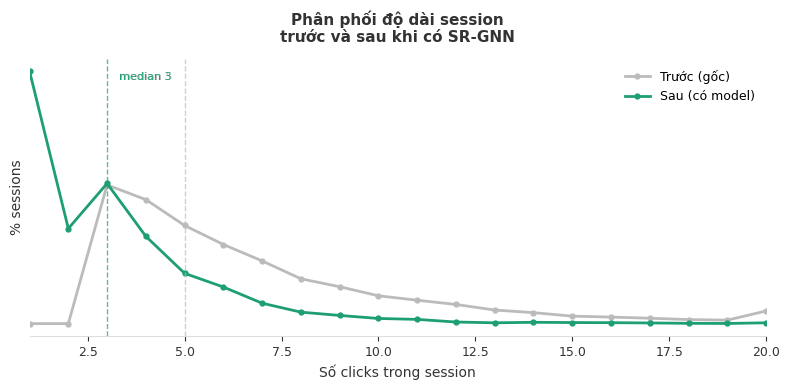

Median before: 5.0 | Median after: 3.0


In [ ]:
# ── CHART 1: PHÂN PHỐI SESSION LENGTH ─────────────────────────────────────────

C_BEFORE = "#BBBBBB"   # neutral gray — baseline
C_AFTER  = "#1D9E75"   # green  — model
C_TEXT   = "#333333"

MAX_LEN = 20   # cap hiển thị, long-tail không kể

fig, ax = plt.subplots(figsize=(8, 4))

for df_s, color, label, zo in [
    (before_sess, C_BEFORE, "Trước (gốc)",    1),
    (after_sess,  C_AFTER,  "Sau (có model)", 2),
]:
    lengths = df_s["n_clicks"].clip(upper=MAX_LEN)
    counts  = lengths.value_counts().sort_index()
    counts  = counts.reindex(range(1, MAX_LEN + 1), fill_value=0)
    pct     = counts / counts.sum() * 100
    ax.plot(pct.index, pct.values,
            color=color, linewidth=2, label=label,
            marker="o", markersize=3.5, zorder=zo)

# Median lines
med_b = before_sess["n_clicks"].clip(upper=MAX_LEN).median()
med_a = after_sess["n_clicks"].clip(upper=MAX_LEN).median()
ax.axvline(med_b, color=C_BEFORE, linewidth=1,   linestyle="--", alpha=0.7)
ax.axvline(med_a, color=C_AFTER,  linewidth=1,   linestyle="--", alpha=0.7)
ax.text(med_b - 0.3, ax.get_ylim()[1] * 0.92,
        f"median {med_b:.0f}", color=C_BEFORE,
        fontsize=8, ha="right")
ax.text(med_a + 0.3, ax.get_ylim()[1] * 0.92,
        f"median {med_a:.0f}", color=C_AFTER,
        fontsize=8, ha="left")

ax.set_xlabel("Số clicks trong session", fontsize=10, color=C_TEXT)
ax.set_ylabel("% sessions", fontsize=10, color=C_TEXT)
ax.set_title("Phân phối độ dài session\ntrước và sau khi có SR-GNN",
             fontsize=11, fontweight="bold", color=C_TEXT, pad=12)

ax.set_xlim(1, MAX_LEN)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#DDDDDD")
ax.tick_params(axis="both", colors=C_TEXT, labelsize=9)
ax.set_yticks([])
ax.grid(False)
ax.legend(frameon=False, fontsize=9, loc="upper right")

plt.tight_layout()
#plt.savefig("chart_01_session_length.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Median before: {before_sess['n_clicks'].median():.1f} | "
      f"Median after: {after_sess['n_clicks'].median():.1f}")

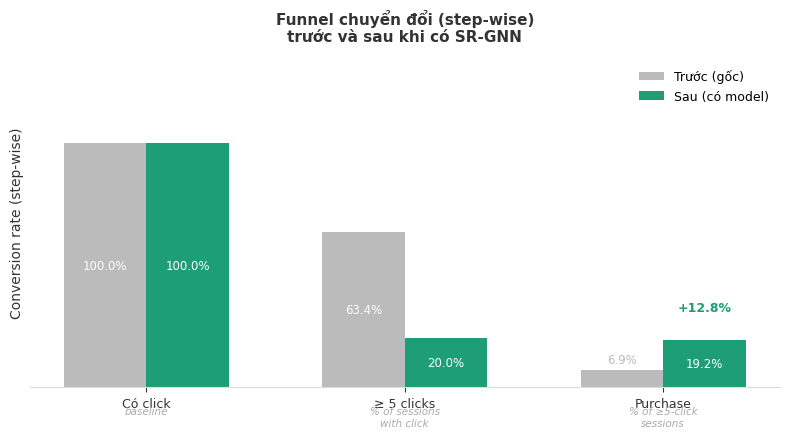

In [47]:
# ── CHART 2: FUNNEL CONVERSION RATE (step-wise) ────────────────────────────────
k = 5
def build_funnel(df_s, label):
    total    = len(df_s)
    over    = (df_s["n_clicks"] >= k).sum()
    purchase = df_s["has_purchase"].sum()
    
    # Step-wise conversion: mẫu số là tầng trên
    pct_click    = 1.0                          # baseline
    pct_over    = over    / total             # % sessions có click → ≥{k} clicks
    pct_purchase = purchase / over             # % sessions ≥{k} clicks → purchase

    return pd.DataFrame({
        "stage" : ["Có click", f"≥ {k} clicks", "Purchase"],
        "count" : [total, over, purchase],
        "pct"   : [pct_click, pct_over, pct_purchase],
        "dataset": label,
    })

funnel_b = build_funnel(before_sess, "Trước (gốc)")
funnel_a = build_funnel(after_sess,  "Sau (có model)")

stages = ["Có click", f"≥ {k} clicks", "Purchase"]
x      = np.arange(len(stages))
width  = 0.32

fig, ax = plt.subplots(figsize=(8, 4.5))

for i, (df_f, color, label) in enumerate([
    (funnel_b, C_BEFORE, "Trước (gốc)"),
    (funnel_a, C_AFTER,  "Sau (có model)"),
]):
    vals = df_f["pct"].values
    bars = ax.bar(x + (i - 0.5) * width, vals,
                  width=width, color=color, label=label, zorder=2)
    for bar, val in zip(bars, vals):
        if val > 0.08:                              # đủ cao thì label trong bar
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 0.5,
                    f"{val:.1%}",
                    ha="center", va="center",
                    fontsize=8.5, color="white", fontweight="500")
        else:                                       # bar thấp thì label trên bar
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.015,
                    f"{val:.1%}",
                    ha="center", va="bottom",
                    fontsize=8.5, color=color, fontweight="500")

# Delta — đẩy lên trên bar cao nhất của tầng Purchase
max_purch = max(pct_b, pct_a)
ax.annotate(
    f"{sign}{delta:.1%}",
    xy=(x[2] + 0.5 * width, max_purch + 0.12),   # cách bar 0.12 units
    fontsize=9, color=C_AFTER, fontweight="bold", ha="center"
)

# Step-wise label giải thích từng tầng
step_labels = [
    "baseline",
    "% of sessions\nwith click",
    f"% of ≥{k}-click\nsessions",
]
for xi, sl in zip(x, step_labels):
    ax.text(xi, -0.08, sl,
            ha="center", va="top",
            fontsize=7.5, color="#AAAAAA", style="italic")

ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=10, color=C_TEXT)
ax.set_ylabel("Conversion rate (step-wise)", fontsize=10, color=C_TEXT)
ax.set_title("Funnel chuyển đổi (step-wise)\ntrước và sau khi có SR-GNN",
             fontsize=11, fontweight="bold", color=C_TEXT, pad=12)
ax.set_ylim(0, 1.35)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#DDDDDD")
ax.tick_params(axis="both", colors=C_TEXT, labelsize=9)
ax.set_yticks([])
ax.grid(False)
ax.legend(frameon=False, fontsize=9, loc="upper right")

plt.tight_layout()
#plt.savefig("chart_02_funnel.png", dpi=150, bbox_inches="tight")
plt.show()

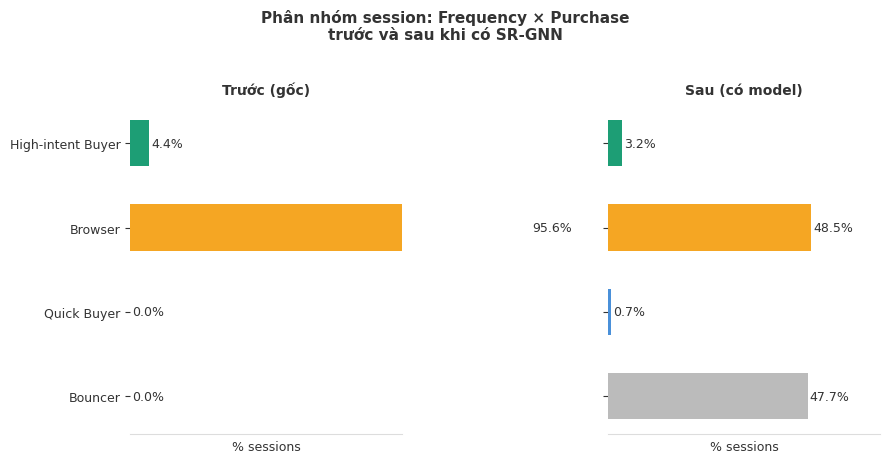

In [45]:
# ── CHART 3: MAPPING 2 CHIỀU — FREQUENCY × PURCHASE ──────────────────────────

CLICK_THRESHOLD = 3   # low = [1,2], high = [3+]

def rfm_segment(df_s):
    df = df_s.copy()
    df["freq_group"] = np.where(df["n_clicks"] >= CLICK_THRESHOLD,
                                f"High clicks (≥{CLICK_THRESHOLD})", f"Low clicks (1–{CLICK_THRESHOLD-1})")
    df["purch_group"] = np.where(df["has_purchase"] == 1,
                                 "Purchase", "No purchase")
    seg = (
        df.groupby(["freq_group", "purch_group"])
        .size()
        .reset_index(name="count")
    )
    seg["pct"] = seg["count"] / seg["count"].sum()
    return seg

seg_b = rfm_segment(before_sess)
seg_a = rfm_segment(after_sess)

SEGMENTS  = [
    (f"High clicks (≥{CLICK_THRESHOLD})", "Purchase",    f"High-intent Buyer"),
    (f"High clicks (≥{CLICK_THRESHOLD})", "No purchase", "Browser"),
    (f"Low clicks (1–{CLICK_THRESHOLD-1})", "Purchase",    "Quick Buyer"),
    (f"Low clicks (1–{CLICK_THRESHOLD-1})", "No purchase", "Bouncer"),
]
SEG_COLORS = {
    f"High-intent Buyer": "#1D9E75",
    "Browser"          : "#F5A623",
    "Quick Buyer"      : "#4A90D9",
    "Bouncer"          : "#BBBBBB",
}

def get_pct(seg_df, freq, purch):
    row = seg_df[(seg_df["freq_group"] == freq) &
                 (seg_df["purch_group"] == purch)]
    return float(row["pct"].values[0]) if len(row) else 0.0

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), sharey=True)

for ax, (seg_df, title) in zip(axes, [
    (seg_b, "Trước (gốc)"),
    (seg_a, "Sau (có model)"),
]):
    vals  = [get_pct(seg_df, f, p) for f, p, _ in SEGMENTS]
    names = [n for _, _, n in SEGMENTS]
    colors= [SEG_COLORS[n] for n in names]

    bars = ax.barh(names[::-1], [v * 100 for v in vals[::-1]],
                   color=colors[::-1], height=0.55, zorder=2)

    for bar, val in zip(bars, vals[::-1]):
        ax.text(bar.get_width() + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.1%}",
                va="center", ha="left",
                fontsize=9, color=C_TEXT)

    ax.set_title(title, fontsize=10, fontweight="bold",
                 color=C_TEXT, pad=8)
    ax.set_xlim(0, 65)
    ax.set_xlabel("% sessions", fontsize=9, color=C_TEXT)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("#DDDDDD")
    ax.tick_params(axis="both", colors=C_TEXT, labelsize=9)
    ax.set_xticks([])
    ax.grid(False)

fig.suptitle("Phân nhóm session: Frequency × Purchase\ntrước và sau khi có SR-GNN",
             fontsize=11, fontweight="bold", color=C_TEXT, y=1.02)
plt.tight_layout()
#plt.savefig("chart_03_rfm_lite.png", dpi=150, bbox_inches="tight")
plt.show()

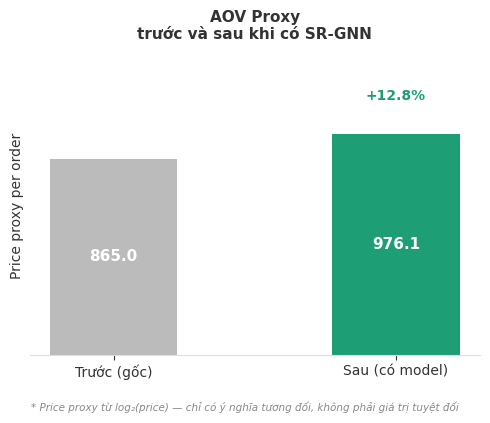

AOV proxy before : 865.05
AOV proxy after  : 976.10
Delta            : +12.8%


In [46]:
# ── CHART 4: AOV PROXY ────────────────────────────────────────────────────────
#
# AOV proxy = tổng captured_value_proxy / số purchase sessions
# captured_value_proxy đã có trong fact_recommendation_eval (dùng log2price)

# Lấy từ eval mart thay vì tính lại từ raw
aov_before = (
    eval_df[eval_df["model_key"] == srgnn_key]
    .groupby("session_id")
    .agg(
        total_value  = ("captured_value_proxy", "sum"),
        has_purchase = ("is_purchase_session",  "max"),
    )
    .reset_index()
)

# Before: dùng toàn bộ sessions
aov_b_val = (
    aov_before[aov_before["has_purchase"] == 1]["total_value"].sum() /
    aov_before["has_purchase"].sum()
)

# After: chỉ tính sessions KHÔNG bị bounce mất purchase
# = sessions trong after_sess có has_purchase == 1
after_purch_sessions = after_sess[after_sess["has_purchase"] == 1]["session_id"]
aov_after_df = aov_before[aov_before["session_id"].isin(after_purch_sessions)]
aov_a_val = (
    aov_after_df["total_value"].sum() /
    len(after_purch_sessions)
)

delta     = (aov_a_val - aov_b_val) / aov_b_val
sign      = "+" if delta >= 0 else ""

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))

labels = ["Trước (gốc)", "Sau (có model)"]
values = [aov_b_val, aov_a_val]
colors = [C_BEFORE, C_AFTER]

bars = ax.bar(labels, values, color=colors, width=0.45, zorder=2)

bars = ax.bar(labels, values, color=colors, width=0.45, zorder=2)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 0.5,          # giữa bar
            f"{val:,.1f}",
            ha="center", va="center",
            fontsize=11, fontweight="600", color="white")

ax.annotate(
    f"{sign}{delta:.1%}",
    xy=(1, aov_a_val + max(values) * 0.15),  
    fontsize=10, color=C_AFTER,
    fontweight="bold", ha="center"
)

ax.set_ylabel("Price proxy per order", fontsize=10, color=C_TEXT)
ax.set_title("AOV Proxy\ntrước và sau khi có SR-GNN",
             fontsize=11, fontweight="bold", color=C_TEXT, pad=12)
ax.set_ylim(0, max(values) * 1.35)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#DDDDDD")
ax.tick_params(axis="both", colors=C_TEXT, labelsize=10)
ax.set_yticks([])
ax.grid(False)

note = "* Price proxy từ log₂(price) — chỉ có ý nghĩa tương đối, không phải giá trị tuyệt đối"
fig.text(0.5, -0.04, note, ha="center", fontsize=7.5, color="#888888", style="italic")

plt.tight_layout()
##plt.savefig("chart_04_aov.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"AOV proxy before : {aov_b_val:,.2f}")
print(f"AOV proxy after  : {aov_a_val:,.2f}")
print(f"Delta            : {sign}{delta:.1%}")